<a href="https://colab.research.google.com/github/merinbenny/AdvancedAngular/blob/master/A2_Question5_Merin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
random.seed(25)
np.random.seed(25)

In [ ]:
data_path = '/content/imbalanced_heart_data.csv'
heart_data = pd.read_csv(data_path)
print("Basic Information of the dataset:")
print(heart_data.dtypes)

print("Statistics")
print(heart_data.describe())


Basic Information of the dataset:
cp           int64
ca           int64
thalach      int64
oldpeak    float64
thal         int64
target       int64
dtype: object
Statistics
               cp          ca     thalach     oldpeak        thal      target
count  549.000000  549.000000  549.000000  549.000000  549.000000  549.000000
mean     0.561020    1.078324  140.845173    1.492532    2.504554    0.094718
std      0.942901    1.039048   23.077379    1.288169    0.685138    0.293092
min      0.000000    0.000000   71.000000    0.000000    0.000000    0.000000
25%      0.000000    0.000000  125.000000    0.300000    2.000000    0.000000
50%      0.000000    1.000000  143.000000    1.200000    3.000000    0.000000
75%      1.000000    2.000000  160.000000    2.400000    3.000000    0.000000
max      3.000000    4.000000  195.000000    6.200000    3.000000    1.000000


In [ ]:
print("Target Value Counts:\n")
print(heart_data['target'].value_counts())

print("\nTarget Proportions:\n")
print(heart_data['target'].value_counts(normalize=True))

Target Value Counts:

target
0    497
1     52
Name: count, dtype: int64

Target Proportions:

target
0    0.905282
1    0.094718
Name: proportion, dtype: float64


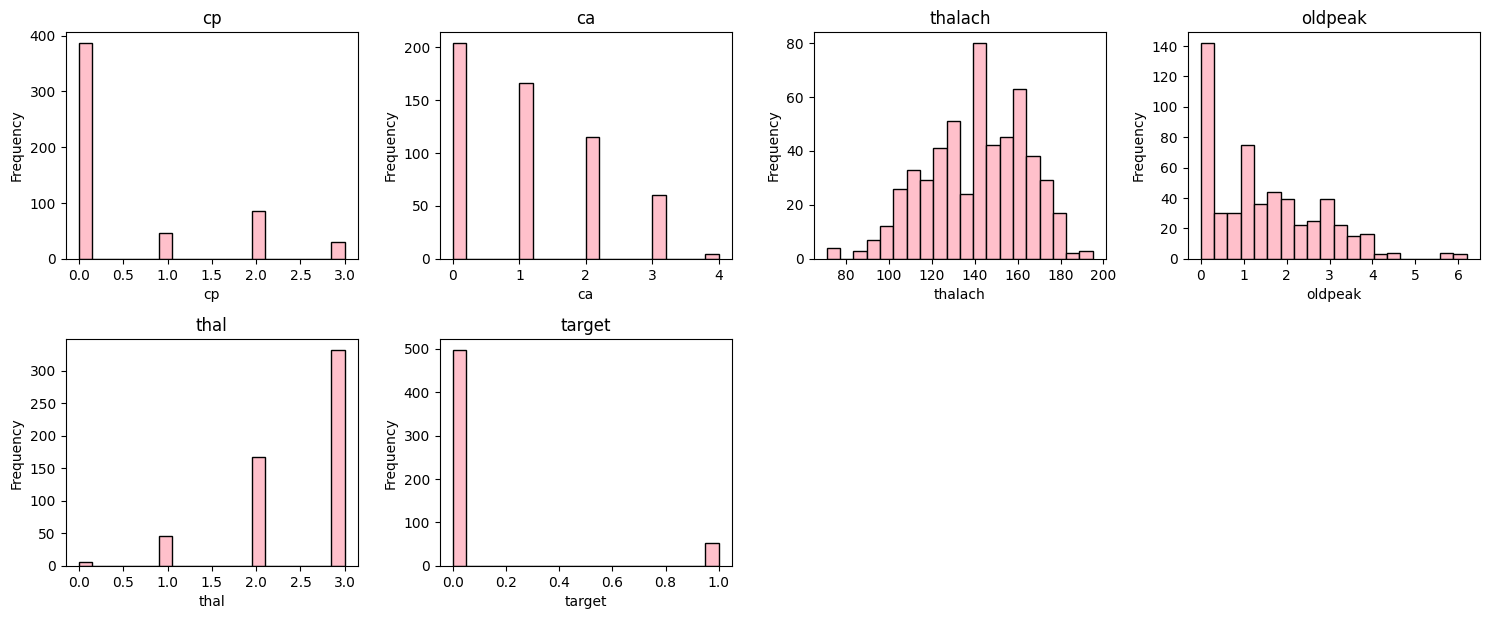

In [ ]:
numerical_cols = heart_data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    plt.hist(heart_data[col], bins=20, color='pink', edgecolor='black')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

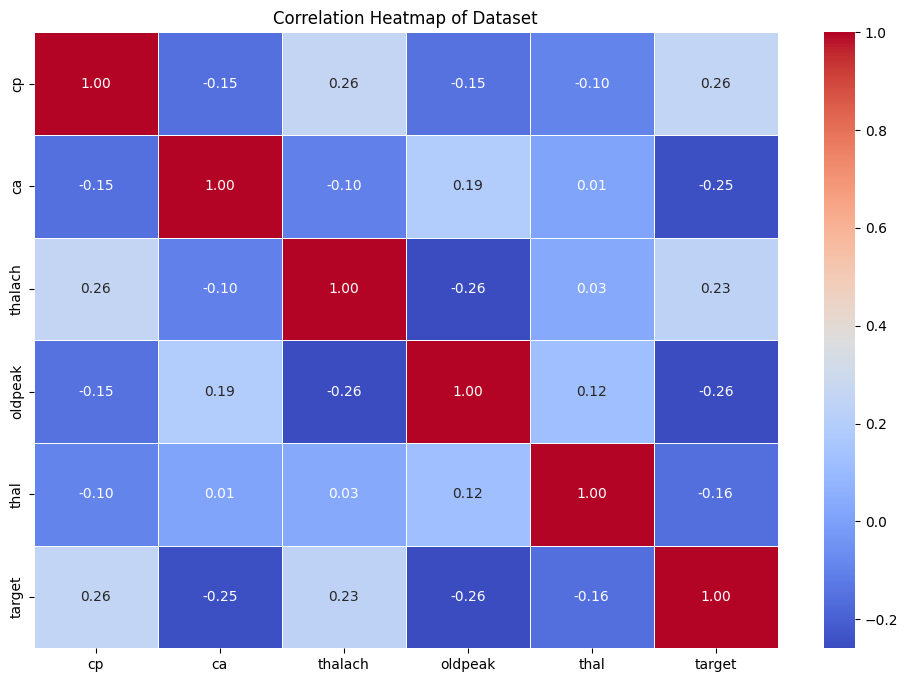

In [ ]:
plt.figure(figsize=(12, 8))
cor_matrix = heart_data.corr()

sns.heatmap(
    cor_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Dataset")
plt.show()


In [ ]:
X = heart_data.drop('target', axis=1)
y = heart_data['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Means of scaled features:\n", X_scaled_df.mean())
print("\nStandard deviations of scaled features:\n", X_scaled_df.std())

Means of scaled features:
 cp         2.912060e-17
ca        -2.264936e-17
thalach   -1.132468e-16
oldpeak    9.059743e-17
thal      -6.471245e-17
dtype: float64

Standard deviations of scaled features:
 cp         1.000912
ca         1.000912
thalach    1.000912
oldpeak    1.000912
thal       1.000912
dtype: float64


In [ ]:
X = X_scaled_df
y = heart_data['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=25
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (439, 5)
X_test shape: (110, 5)
y_train shape: (439,)
y_test shape: (110,)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_accuracy)


KNN Accuracy: 0.9363636363636364


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt = DecisionTreeClassifier(max_depth=5, random_state=2)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.9272727272727272


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear'
)

log_l2.fit(X_train, y_train)

log_l2_pred = log_l2.predict(X_test)

log_l2_accuracy = accuracy_score(y_test, log_l2_pred)
print("Logistic Regression (L2) Accuracy:", log_l2_accuracy)


Logistic Regression (L2) Accuracy: 0.9272727272727272


In [ ]:

log_l1 = LogisticRegression(
    penalty='l1',
    C=0.1,
    solver='liblinear'
)

log_l1.fit(X_train, y_train)

log_l1_pred = log_l1.predict(X_test)

log_l1_accuracy = accuracy_score(y_test, log_l1_pred)
print("Logistic Regression (L1) Accuracy:", log_l1_accuracy)


Logistic Regression (L1) Accuracy: 0.9090909090909091


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred))


              precision    recall  f1-score   support

           0       0.93      1.00      0.97       100
           1       1.00      0.30      0.46        10

    accuracy                           0.94       110
   macro avg       0.97      0.65      0.71       110
weighted avg       0.94      0.94      0.92       110



In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

models = {
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Logistic Regression (L2)": log_l2_pred,
    "Logistic Regression (L1)": log_l1_pred
}

for name, pred in models.items():
    print(f"\n{name} Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))



KNN Confusion Matrix:
[[100   0]
 [  7   3]]
Precision: 1.0
Recall: 0.3
F1 Score: 0.46153846153846156

Decision Tree Confusion Matrix:
[[98  2]
 [ 6  4]]
Precision: 0.6666666666666666
Recall: 0.4
F1 Score: 0.5

Logistic Regression (L2) Confusion Matrix:
[[100   0]
 [  8   2]]
Precision: 1.0
Recall: 0.2
F1 Score: 0.3333333333333333

Logistic Regression (L1) Confusion Matrix:
[[100   0]
 [ 10   0]]
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

log_balanced = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    class_weight='balanced'
)
log_balanced.fit(X_train, y_train)
log_balanced_pred = log_balanced.predict(X_test)

print("Baseline Logistic Regression (L2) Confusion Matrix:")
print(confusion_matrix(y_test, log_l2_pred))
print("Recall (baseline):", recall_score(y_test, log_l2_pred))

print("\nBalanced Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, log_balanced_pred))
print("Recall (balanced):", recall_score(y_test, log_balanced_pred))


Baseline Logistic Regression (L2) Confusion Matrix:
[[100   0]
 [  8   2]]
Recall (baseline): 0.2

Balanced Logistic Regression Confusion Matrix:
[[79 21]
 [ 1  9]]
Recall (balanced): 0.9


In [ ]:
from sklearn.utils import resample
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score
y_train_np = y_train.to_numpy()


train_data = np.hstack((X_train, y_train_np.reshape(-1,1)))
majority = train_data[train_data[:,-1] == 0]
minority = train_data[train_data[:,-1] == 1]

minority_oversampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=25
)

balanced_train = np.vstack((majority, minority_oversampled))
np.random.shuffle(balanced_train)

X_train_bal = balanced_train[:,:-1]
y_train_bal = balanced_train[:,-1]

log_over = LogisticRegression(solver='liblinear')
log_over.fit(X_train_bal, y_train_bal)

log_over_pred = log_over.predict(X_test)

print("Oversampled Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, log_over_pred))
print("Recall (oversampled):", recall_score(y_test, log_over_pred))


Oversampled Logistic Regression Confusion Matrix:
[[79 21]
 [ 1  9]]
Recall (oversampled): 0.9


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


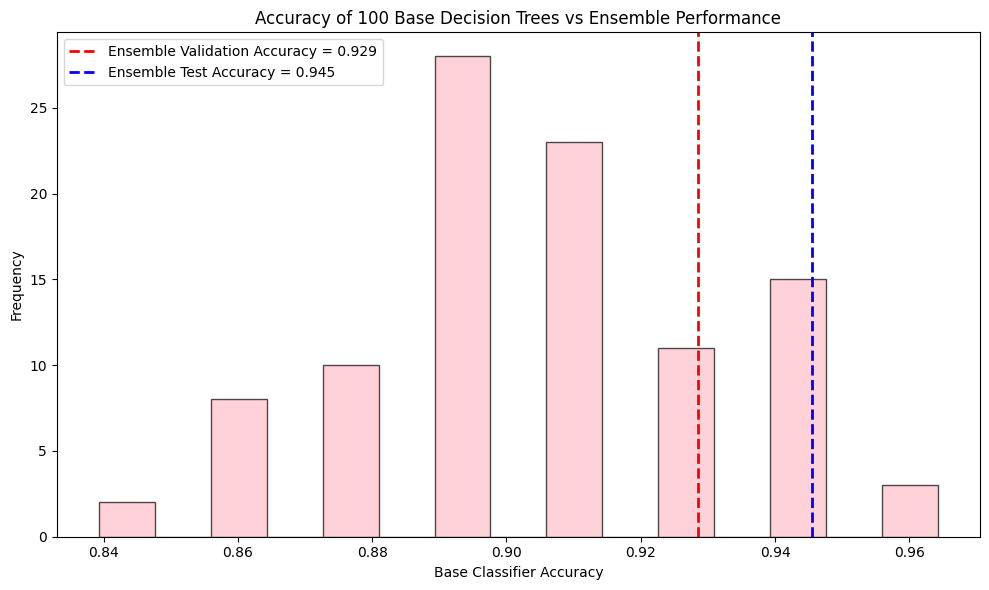

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=25,
    stratify=y_train
)

X_train = X_train2
y_train = y_train2

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_val_np = X_val.to_numpy()
y_val_np = y_val.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

base_accuracies = []
val_preds = []
test_preds = []

for i in range(100):
    idx = np.random.choice(len(X_train_np), len(X_train_np), replace=True)
    Xb, yb = X_train_np[idx], y_train_np[idx]

    model = DecisionTreeClassifier()
    model.fit(Xb, yb)

    acc = accuracy_score(y_val_np, model.predict(X_val_np))
    base_accuracies.append(acc)

    val_preds.append(model.predict(X_val_np))
    test_preds.append(model.predict(X_test_np))

val_preds = np.array(val_preds)
test_preds = np.array(test_preds)

ensemble_val = np.round(val_preds.mean(axis=0))
ensemble_test = np.round(test_preds.mean(axis=0))

ensemble_val_acc = accuracy_score(y_val_np, ensemble_val)
ensemble_test_acc = accuracy_score(y_test_np, ensemble_test)

plt.figure(figsize=(10,6))
plt.hist(base_accuracies, bins=15, color='pink', edgecolor='black', alpha=0.7)

plt.axvline(ensemble_val_acc, color='red', linestyle='--', linewidth=2,
            label=f'Ensemble Validation Accuracy = {ensemble_val_acc:.3f}')
plt.axvline(ensemble_test_acc, color='blue', linestyle='--', linewidth=2,
            label=f'Ensemble Test Accuracy = {ensemble_test_acc:.3f}')

plt.title("Accuracy of 100 Base Decision Trees vs Ensemble Performance")
plt.xlabel("Base Classifier Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#End of question 5

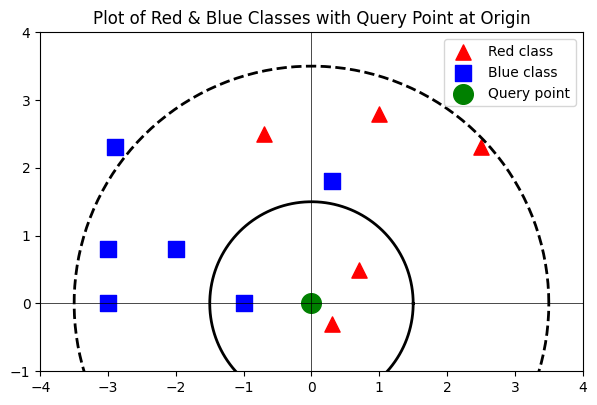

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


red = np.array([
    [0.3, -0.3],
    [0.7, 0.5],
    [-0.7, 2.5],
    [1.0, 2.8],
    [2.5, 2.3]
])


blue = np.array([
    [0.3, 1.8],
    [-1.0, 0.0],
    [-2.0, 0.8],
    [-3.0, -0.0],
    [-3.0, 0.8],
    [-2.9, 2.3]
])


green = np.array([0, 0])


plt.figure(figsize=(7,7))

# Plot red triangles
plt.scatter(red[:,0], red[:,1], marker='^', color='red', s=120, label='Red class')

# Plot blue squares
plt.scatter(blue[:,0], blue[:,1], marker='s', color='blue', s=120, label='Blue class')

# Plot green query point
plt.scatter(green[0], green[1], color='green', s=200, label='Query point')


inner_radius = 1.5
outer_radius = 3.5
theta = np.linspace(0, 2*np.pi, 300)

plt.plot(inner_radius*np.cos(theta), inner_radius*np.sin(theta), 'k-', linewidth=2)
plt.plot(outer_radius*np.cos(theta), outer_radius*np.sin(theta), 'k--', linewidth=2)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.xlim(-4, 4)
plt.ylim(-1, 4)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Plot of Red & Blue Classes with Query Point at Origin")
plt.legend()
plt.show()


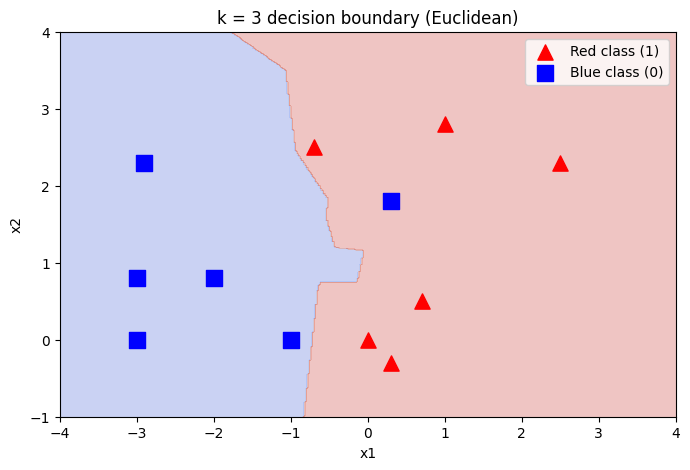

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

red = np.array([
    [0.3, -0.3],
    [0.7, 0.5],
    [-0.7, 2.5],
    [1.0, 2.8],
    [2.5, 2.3]
])


blue = np.array([
    [0.3, 1.8],
    [-1.0, 0.0],
    [-2.0, 0.8],
    [-3.0, 0.0],
    [-3.0, 0.8],
    [-2.9, 2.3]
])

X = np.vstack([red, blue])
y = np.array([1]*len(red) + [0]*len(blue))

# -----------------------------
# Train k-NN with k = 3
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X, y)


x_min, x_max = -4, 4
y_min, y_max = -1, 4

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid).reshape(xx.shape)


plt.figure(figsize=(7,7))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Training points
plt.scatter(red[:,0], red[:,1], marker='^', color='red', s=120, label='Red class (1)')
plt.scatter(blue[:,0], blue[:,1], marker='s', color='blue', s=120, label='Blue class (0)')


plt.scatter(0, 0,marker='^', color='red', s=120)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('k = 3 decision boundary (Euclidean)')
plt.legend()
plt.tight_layout()
plt.show()


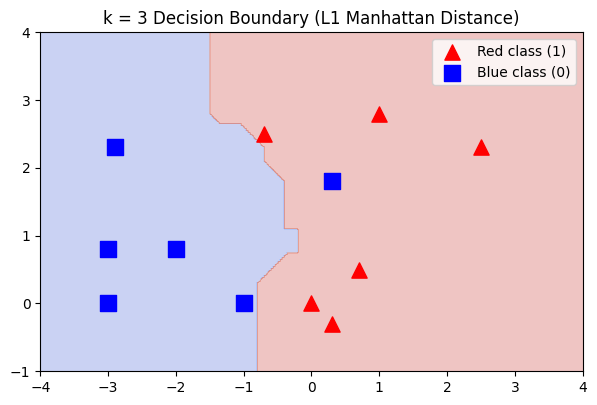

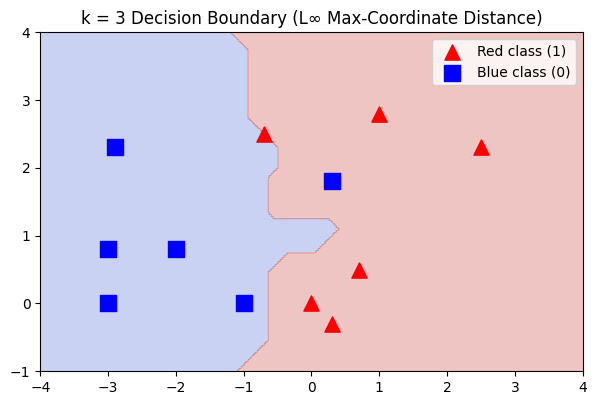

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Your coordinates
# -----------------------------

# Red class (label 1)
red = np.array([
    [0.3, -0.3],
    [0.7, 0.5],
    [-0.7, 2.5],
    [1.0, 2.8],
    [2.5, 2.3]
])

# Blue class (label 0)
blue = np.array([
    [0.3, 1.8],
    [-1.0, 0.0],
    [-2.0, 0.8],
    [-3.0, 0.0],
    [-3.0, 0.8],
    [-2.9, 2.3]
])

# Query point (0,0)
query = np.array([[0.0, 0.0]])

# Combine data
X = np.vstack([red, blue])
y = np.array([1]*len(red) + [0]*len(blue))

# -----------------------------
# Create grid for plotting
# -----------------------------
x_min, x_max = -4, 4
y_min, y_max = -1, 4

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# -----------------------------
# Train kNN models
# -----------------------------
knn_L1 = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_Linf = KNeighborsClassifier(n_neighbors=3, metric='chebyshev')

knn_L1.fit(X, y)
knn_Linf.fit(X, y)

Z_L1 = knn_L1.predict(grid).reshape(xx.shape)
Z_Linf = knn_Linf.predict(grid).reshape(xx.shape)

# -----------------------------
# Plot L1 (Manhattan)
# -----------------------------
plt.figure(figsize=(7,7))
plt.contourf(xx, yy, Z_L1, alpha=0.3, cmap='coolwarm')

plt.scatter(red[:,0], red[:,1], marker='^', color='red', s=120, label='Red class (1)')
plt.scatter(blue[:,0], blue[:,1], marker='s', color='blue', s=120, label='Blue class (0)')

# Add query point
plt.scatter(query[0,0], query[0,1], marker='^', color='red', s=120)

plt.title("k = 3 Decision Boundary (L1 Manhattan Distance)")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

# -----------------------------
# Plot L∞ (Chebyshev)
# -----------------------------
plt.figure(figsize=(7,7))
plt.contourf(xx, yy, Z_Linf, alpha=0.3, cmap='coolwarm')

plt.scatter(red[:,0], red[:,1], marker='^', color='red', s=120, label='Red class (1)')
plt.scatter(blue[:,0], blue[:,1], marker='s', color='blue', s=120, label='Blue class (0)')

# Add query point
plt.scatter(query[0,0], query[0,1], marker='^', color='red', s=120)

plt.title("k = 3 Decision Boundary (L∞ Max-Coordinate Distance)")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()


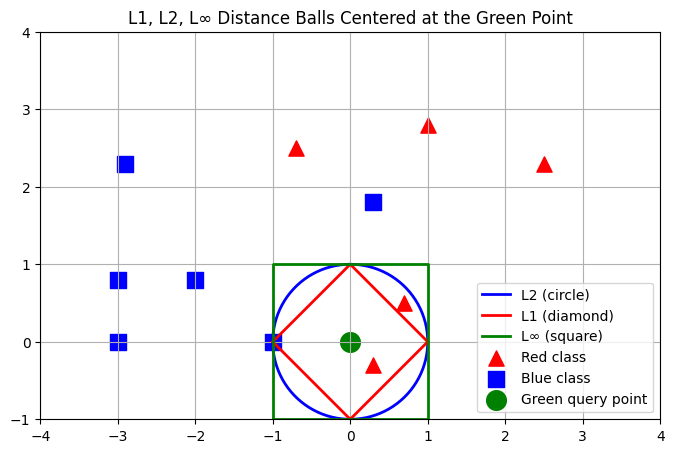

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


red = np.array([
    [0.3, -0.3],
    [0.7, 0.5],
    [-0.7, 2.5],
    [1.0, 2.8],
    [2.5, 2.3]
])

blue = np.array([
    [0.3, 1.8],
    [-1.0, 0.0],
    [-2.0, 0.8],
    [-3.0, 0.0],
    [-3.0, 0.8],
    [-2.9, 2.3]
])

green = np.array([0, 0])
plt.figure(figsize=(8,8))


theta = np.linspace(0, 2*np.pi, 300)
x_L2 = np.cos(theta)
y_L2 = np.sin(theta)
plt.plot(x_L2, y_L2, 'b-', linewidth=2, label='L2 (circle)')


x_L1 = np.linspace(-1, 1, 400)
y_L1_top = 1 - np.abs(x_L1)
y_L1_bottom = -y_L1_top
plt.plot(x_L1, y_L1_top, 'r-', linewidth=2, label='L1 (diamond)')
plt.plot(x_L1, y_L1_bottom, 'r-', linewidth=2)


square_x = [-1, 1, 1, -1, -1]
square_y = [-1, -1, 1, 1, -1]
plt.plot(square_x, square_y, 'g-', linewidth=2, label='L∞ (square)')


plt.scatter(red[:,0], red[:,1], marker='^', color='red', s=120, label='Red class')
plt.scatter(blue[:,0], blue[:,1], marker='s', color='blue', s=120, label='Blue class')


plt.scatter(0, 0, color='green', s=200, label='Green query point')


plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-4, 4)
plt.ylim(-1, 4)
plt.title("L1, L2, L∞ Distance Balls Centered at the Green Point")
plt.legend()
plt.grid(True)
plt.show()


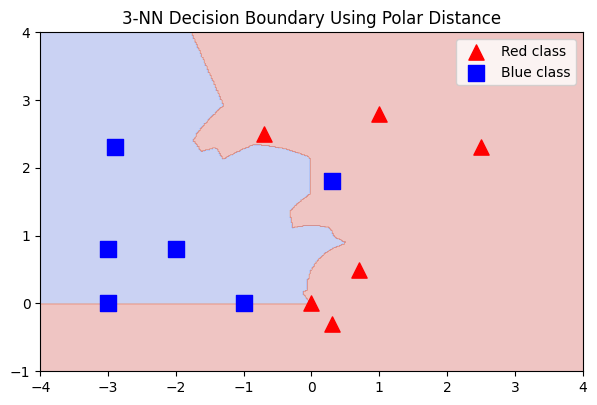

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


def to_polar(X):
    r = np.sqrt(X[:,0]**2 + X[:,1]**2)
    theta = np.arctan2(X[:,1], X[:,0])
    return np.vstack([r, theta]).T


def polar_distance(a, b):
    return np.abs(a[0] - b[0]) + np.abs(a[1] - b[1])

red = np.array([
    [0.3, -0.3],
    [0.7, 0.5],
    [-0.7, 2.5],
    [1.0, 2.8],
    [2.5, 2.3],
    [0,0]
])

blue = np.array([
    [0.3, 1.8],
    [-1.0, 0.0],
    [-2.0, 0.8],
    [-3.0, 0.0],
    [-3.0, 0.8],
    [-2.9, 2.3]
])

X = np.vstack([red, blue])
y = np.array([1]*len(red) + [0]*len(blue))


X_polar = to_polar(X)


xx, yy = np.meshgrid(
    np.linspace(-4, 4, 400),
    np.linspace(-1, 4, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_polar = to_polar(grid)


Z = np.zeros(len(grid_polar))

for i, gp in enumerate(grid_polar):

    dists = np.array([polar_distance(gp, xp) for xp in X_polar])
    nn_idx = np.argsort(dists)[:3]
    votes = y[nn_idx]
    Z[i] = 1 if np.sum(votes) >= 2 else 0

Z = Z.reshape(xx.shape)


plt.figure(figsize=(7,7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(red[:,0], red[:,1], marker='^', color='red', s=120, label='Red class')
plt.scatter(blue[:,0], blue[:,1], marker='s', color='blue', s=120, label='Blue class')

plt.title("3-NN Decision Boundary Using Polar Distance")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()


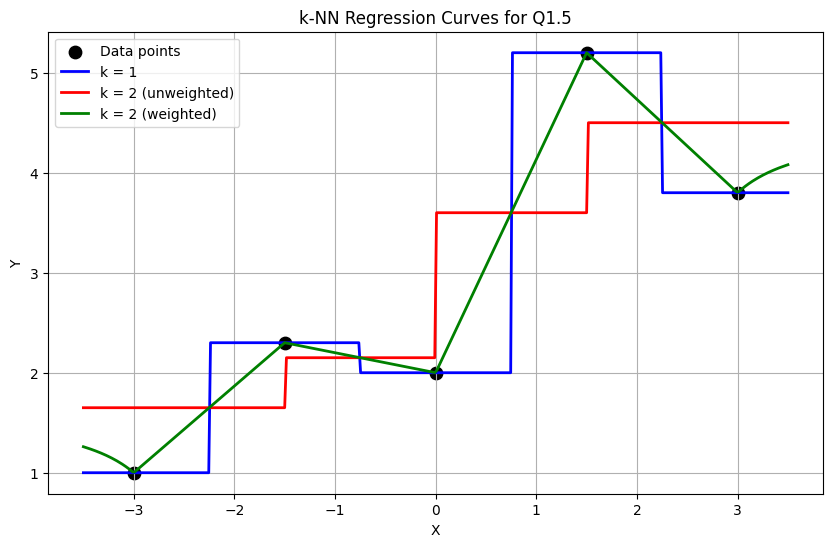

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array([-3, -1.5, 0, 1.5, 3])
Y = np.array([1, 2.3, 2, 5.2, 3.8])


idx = np.argsort(X)
X = X[idx]
Y = Y[idx]


def nearest_neighbors(x, X, k):
    dists = np.abs(X - x)
    nn_idx = np.argsort(dists)[:k]
    return nn_idx, dists[nn_idx]


def knn1_predict(x, X, Y):
    nn_idx, _ = nearest_neighbors(x, X, 1)
    return Y[nn_idx][0]


def knn2_unweighted_predict(x, X, Y):
    nn_idx, _ = nearest_neighbors(x, X, 2)
    return np.mean(Y[nn_idx])

def knn2_weighted_predict(x, X, Y):
    nn_idx, dists = nearest_neighbors(x, X, 2)

    dists = np.where(dists == 0, 1e-8, dists)
    weights = 1 / dists
    return np.sum(weights * Y[nn_idx]) / np.sum(weights)


x_grid = np.linspace(-3.5, 3.5, 400)

y_k1 = np.array([knn1_predict(x, X, Y) for x in x_grid])
y_k2_un = np.array([knn2_unweighted_predict(x, X, Y) for x in x_grid])
y_k2_wt = np.array([knn2_weighted_predict(x, X, Y) for x in x_grid])

plt.figure(figsize=(10,6))


plt.scatter(X, Y, color='black', s=80, label='Data points')


plt.plot(x_grid, y_k1, color='blue', linewidth=2, label='k = 1')
plt.plot(x_grid, y_k2_un, color='red', linewidth=2, label='k = 2 (unweighted)')
plt.plot(x_grid, y_k2_wt, color='green', linewidth=2, label='k = 2 (weighted)')

plt.title("k-NN Regression Curves for Q1.5")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()
